In [1]:
import numpy as np
import torch
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import pandas as pd
import os
import re
import polars as pl
from collections import defaultdict
import matplotlib.gridspec as gridspec

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
mc_path = "/home/aegis/Titan1/NRAD/data/Regions_MC_ver2"
data_path = "/home/aegis/Titan1/NRAD/data/Regions_data_ver3"

mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]

columns_to_load_mc = [
    "raw_weights", "weight_ngen", "weight_sub_weight", "weight_tot_weight",
    "met_recalc_pt", "met_recalc_phi",
    "ht", # <- Make sure HT is here so you don't have to recalculate it!
    
    # --- CHANGE THESE TO THE POST-OR BRANCHES ---
    "post_OR_jet_pt", 
    "post_OR_jet_eta", 
    "post_OR_jet_phi", 
    
    # --- LARGE R JETS STAY THE SAME ---
    "AnalysisLargeRJetsAuxDyn_pt", 
    "AnalysisLargeRJetsAuxDyn_eta", 
    "AnalysisLargeRJetsAuxDyn_phi", 
    "AnalysisLargeRJetsAuxDyn_Tau1_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau2_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau3_wta"
]

# Make sure you do the same for your data columns!
columns_to_load_data = [
    "met_recalc_pt", "met_recalc_phi",
    "ht",
    "post_OR_jet_pt", 
    "post_OR_jet_eta", 
    "post_OR_jet_phi", 
    "AnalysisLargeRJetsAuxDyn_pt", 
    "AnalysisLargeRJetsAuxDyn_eta", 
    "AnalysisLargeRJetsAuxDyn_phi", 
    "AnalysisLargeRJetsAuxDyn_Tau1_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau2_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau3_wta"
]

### Check MC Distributions

In [3]:
MC_CR1L_paths = glob.glob(os.path.join(mc_path, "CR_1L", "*.parquet"))
MC_CR1L1B_paths = glob.glob(os.path.join(mc_path, "CR_1L1B", "*.parquet"))
MC_CR2L_paths = glob.glob(os.path.join(mc_path, "CR_2L", "*.parquet"))
MC_CR0L_paths = glob.glob(os.path.join(mc_path, "CR_MJRR", "*.parquet"))
MC_SR_paths = glob.glob(os.path.join(mc_path, "SR", "*.parquet"))

print("W+jets dominated background (CR1L) files", len(MC_CR1L_paths))
print("Top dominated background (CR1L1B) files", len(MC_CR1L1B_paths))
print("Z+jets dominated background (CR2L) files", len(MC_CR2L_paths))
print("Multijet dominated background (CR0L) files", len(MC_CR0L_paths))
print("Signal region (SR) files", len(MC_SR_paths))

print()
print("="*50)
print()

DATA_CR1L_paths = glob.glob(os.path.join(data_path, "CR_1L", "*.parquet"))
DATA_CR1L1B_paths = glob.glob(os.path.join(data_path, "CR_1L1B", "*.parquet"))
DATA_CR2L_paths = glob.glob(os.path.join(data_path, "CR_2L", "*.parquet"))
DATA_CR0L_paths = glob.glob(os.path.join(data_path, "CR_MJRR", "*.parquet"))
DATA_SR_paths = glob.glob(os.path.join(data_path, "SR", "*.parquet"))

print("W+jets dominated background (CR1L) data files", len(DATA_CR1L_paths))
print("Top dominated background (CR1L1B) data files", len(DATA_CR1L1B_paths))
print("Z+jets dominated background (CR2L) data files", len(DATA_CR2L_paths))
print("Multijet dominated background (CR0L) data files", len(DATA_CR0L_paths))
print("Signal region (SR) data files", len(DATA_SR_paths))

W+jets dominated background (CR1L) files 3387
Top dominated background (CR1L1B) files 2533
Z+jets dominated background (CR2L) files 931
Multijet dominated background (CR0L) files 4301
Signal region (SR) files 3782


W+jets dominated background (CR1L) data files 21903
Top dominated background (CR1L1B) data files 11554
Z+jets dominated background (CR2L) data files 1751
Multijet dominated background (CR0L) data files 40409
Signal region (SR) data files 13264


In [4]:
def calc_features(lf: pl.LazyFrame, is_MC) -> pl.LazyFrame:
    """
    Calculates Mjj and tau ratios using the cleaned Parquet features, 
    then discards all low-level vectors.
    """
    # 1. Extract the specific elements using the CLEANED branches (post_OR)
    lf = lf.with_columns(
        j1_pt  = pl.col("post_OR_jet_pt").list.get(0),
        j2_pt  = pl.col("post_OR_jet_pt").list.get(1),
        j1_eta = pl.col("post_OR_jet_eta").list.get(0),
        j2_eta = pl.col("post_OR_jet_eta").list.get(1),
        j1_phi = pl.col("post_OR_jet_phi").list.get(0),
        j2_phi = pl.col("post_OR_jet_phi").list.get(1),
        
        # Large-R Jet Taus (No OR was applied to these, so raw branches are fine)
        lrj1_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(0),
        lrj1_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(0),
        lrj1_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(0),
        lrj2_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(1),
        lrj2_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(1),
        lrj2_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(1),
    )

    # 2. Calculate the final complex math
    lf = lf.with_columns(
        # Mjj formula: Removed / 1000.0 because post_OR_jet_pt is already in GeV
        mjj = (
            2 * pl.col("j1_pt") * pl.col("j2_pt") * ((pl.col("j1_eta") - pl.col("j2_eta")).cosh() - (pl.col("j1_phi") - pl.col("j2_phi")).cos())
        ).sqrt(),
        
        # Subjettiness ratios (with safe division)
        ljet1_tau21 = pl.when(pl.col("lrj1_t1") > 0).then(pl.col("lrj1_t2") / pl.col("lrj1_t1")).otherwise(0),
        ljet1_tau32 = pl.when(pl.col("lrj1_t2") > 0).then(pl.col("lrj1_t3") / pl.col("lrj1_t2")).otherwise(0),
        ljet2_tau21 = pl.when(pl.col("lrj2_t1") > 0).then(pl.col("lrj2_t2") / pl.col("lrj2_t1")).otherwise(0),
        ljet2_tau32 = pl.when(pl.col("lrj2_t2") > 0).then(pl.col("lrj2_t3") / pl.col("lrj2_t2")).otherwise(0),
    )

    # 3. KEEP ONLY WHAT YOU ASKED FOR. Everything else is flushed from memory.
    if is_MC:
        final_columns = [
            "mc_process", "subprocess",                                              
            "raw_weights", "weight_ngen", "weight_sub_weight", "weight_tot_weight",  
            "met_recalc_pt", "met_recalc_phi",                                       
            "ht", "mjj",                                                             # HT is native to the parquet now
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               
        ]
    else:
        final_columns = [                                                            
            "met_recalc_pt", "met_recalc_phi",                                       
            "ht", "mjj",                                                             
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               
        ]
        
    return lf.select(final_columns)

def get_lazyframes(paths, is_mc):
    # Move this OUTSIDE the loop so it doesn't overwrite on every iteration
    files_by_meta = defaultdict(list)
    known_processes = ['Wjets', 'Zjets', 'ttbar', 'Diboson', 'Multijet', 'Single_top']
    
    for filepath in paths:
        filename = os.path.basename(filepath)
        
        if is_mc:
            # Identify the main mc_process
            mc_process = next((p for p in known_processes if filename.startswith(p)), "Other")
            
            # Clean the filename to extract just the subprocess
            name_no_ext = filename.replace(".parquet", "")
            
            if name_no_ext.startswith(mc_process + "_"):
                remainder = name_no_ext[len(mc_process) + 1:]
            else:
                remainder = name_no_ext
                
            # STRIP THE BATCH: This removes "_batch1762" from the end of the string
            subprocess = re.sub(r"_batch\d+$", "", remainder) 
            
            # Group all batches of the same subprocess together
            files_by_meta[(mc_process, subprocess)].append(filepath)
        else:
            # If it's real data, bypass the naming logic and group them all together
            # print(filepath)
            files_by_meta[("Data", "Data")].append(filepath)

    # Load the data into the DataFrame list
    lazy_frames = []

    # group_paths now contains ALL batch files for this specific key
    for (mc_process, subprocess), group_paths in files_by_meta.items():
        if is_mc:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_mc)
            # Tag them with the clean labels only if it's Monte Carlo
            lf = lf.with_columns(
                pl.lit(mc_process).alias("mc_process"),
                pl.lit(subprocess).alias("subprocess")
            )
        else:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_data)
            
        lf = calc_features(lf, is_mc)
        lazy_frames.append(lf)

    return lazy_frames

def apply_final_weights(df_mc: pl.DataFrame, meta_df: pl.DataFrame) -> pl.DataFrame:
    """
    Applies the official scale factors and empirical scaling to generate 'final_weight'.
    """
    df_mc = df_mc.join(meta_df, on="subprocess", how="left")

    LUMI = 25.289004522843967
    
    df_mc = df_mc.with_columns(
        official_scale_factor = (
            pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
        ) / pl.col("sum_w_pros")
    )

    TTBAR_PROCESSES = [
        "PhPy8EG_A14_ttbar_hdamp258p75_nonallhad",
        "PhPy8EG_A14_ttbar_hdamp258p75_allhad"
    ]
    TTBAR_SCALE = 1.7

    JET_PROCESSES = [f"Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ{i}WithSW" for i in range(13)]
    JET_SCALE = 0.4

    Z_PROCESS_SCALE = 1.4
    Z_PROCESSES = [
        "Sh_2211_Zmumu_maxHTpTV2_BFilter", 
        "Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto", 
        "Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto", 
        "Sh_2211_Znunu_pTV2_BFilter", 
        "Sh_2211_Znunu_pTV2_CFilterBVeto", 
        "Sh_2211_Znunu_pTV2_CVetoBVeto"
    ]

    W_PROCESS_SCALE = 1.3  
    W_PROCESSES = [
        "Sh_2211_Wenu_maxHTpTV2_BFilter",
        "Sh_2211_Wenu_maxHTpTV2_CFilterBVeto",
        "Sh_2211_Wenu_maxHTpTV2_CVetoBVeto",
        "Sh_2211_Wmunu_maxHTpTV2_BFilter",
        "Sh_2211_Wmunu_maxHTpTV2_CFilterBVeto",
        "Sh_2211_Wmunu_maxHTpTV2_CVetoBVeto",
        "Sh_2211_Wtaunu_L_maxHTpTV2_BFilter",
        "Sh_2211_Wtaunu_L_maxHTpTV2_CFilterBVeto",
        "Sh_2211_Wtaunu_L_maxHTpTV2_CVetoBVeto",
        "Sh_2211_Wtaunu_H_maxHTpTV2_BFilter",
        "Sh_2211_Wtaunu_H_maxHTpTV2_CFilterBVeto",
        "Sh_2211_Wtaunu_H_maxHTpTV2_CVetoBVeto"
    ]

    return df_mc.with_columns(
        final_weight = pl.when(pl.col("subprocess").is_in(JET_PROCESSES))
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * JET_SCALE)
        .when(pl.col("subprocess").is_in(Z_PROCESSES))
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * Z_PROCESS_SCALE)
        .when(pl.col("subprocess").is_in(W_PROCESSES))
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * W_PROCESS_SCALE)
        .when(pl.col("subprocess").is_in(TTBAR_PROCESSES))
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * TTBAR_SCALE)
        .otherwise(pl.col("official_scale_factor") * pl.col("raw_weights"))
    )

#### Process CR1L 
W+jets dominated background

In [5]:
MC_CR1L_lazy = get_lazyframes(MC_CR1L_paths, is_mc=True)
DATA_CR1L_lazy = get_lazyframes(DATA_CR1L_paths, is_mc=False)
# Execute the read and combine everything
MC_CR1L = pl.concat(MC_CR1L_lazy).collect()
DATA_CR1L = pl.concat(DATA_CR1L_lazy).collect()

#### Process CR1L1B
Top Dominated Background

In [6]:
MC_CR1L1B_lazy = get_lazyframes(MC_CR1L1B_paths, is_mc=True)
DATA_CR1L1B_lazy = get_lazyframes(DATA_CR1L1B_paths, is_mc=False)
# Execute the read and combine everything
MC_CR1L1B = pl.concat(MC_CR1L1B_lazy).collect()
DATA_CR1L1B = pl.concat(DATA_CR1L1B_lazy).collect()

#### Process CR2L
Z+jets dominated background

In [7]:
MC_CR2L_lazy = get_lazyframes(MC_CR2L_paths, is_mc=True)
DATA_CR2L_lazy = get_lazyframes(DATA_CR2L_paths, is_mc=False)
# Execute the read and combine everything
MC_CR2L = pl.concat(MC_CR2L_lazy).collect()
DATA_CR2L = pl.concat(DATA_CR2L_lazy).collect()

#### Process CR0L
Multijet dominated background

In [8]:
MC_CR0L_lazy = get_lazyframes(MC_CR0L_paths, is_mc=True)
DATA_CR0L_lazy = get_lazyframes(DATA_CR0L_paths, is_mc=False)
MC_CR0L = pl.concat(MC_CR0L_lazy).collect()
DATA_CR0L = pl.concat(DATA_CR0L_lazy).collect()

#### Process SR
The Signal Region

In [9]:
MC_SR_lazy = get_lazyframes(MC_SR_paths, is_mc=True)
DATA_SR_lazy = get_lazyframes(DATA_SR_paths, is_mc=False)
MC_SR = pl.concat(MC_SR_lazy).collect()
DATA_SR = pl.concat(DATA_SR_lazy).collect()

In [10]:
# 1. Load the official metadata from the CSV
meta_df = pl.read_csv("metadata_processed.csv").select([
    "physics_short", 
    "crossSection_pb", 
    "genFiltEff", 
    "kFactor",
    "sumOfWeights",
    "sum_w_pros", 
    "scale_factor_sub_weight", 
    "luminosity"
]).rename({"physics_short": "subprocess"})

def plot_mc_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
    """
    Plots Data vs MC using native ATLAS scale factor calculations.
    """

    # df_mc = df_mc.join(meta_df, on="subprocess", how="left")

    # LUMI = 25.289004522843967
    
    # df_mc = df_mc.with_columns(
    #     official_scale_factor = (
    #         pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
    #     ) / pl.col("sum_w_pros")
    # )
    # off_scale = df_mc.select(pl.col("official_scale_factor").first()).item()
    # sub_weight = df_mc.select(pl.col("scale_factor_sub_weight").first()).item()

    # print(f"Official Scale Factor:     {off_scale:.6e}")
    # print(f"Scale Factor Sub-Weight:   {sub_weight:.6e}")

    # TTBAR_PROCESSES = [
    #     "PhPy8EG_A14_ttbar_hdamp258p75_nonallhad",
    #     "PhPy8EG_A14_ttbar_hdamp258p75_allhad"
    # ]
    # TTBAR_SCALE = 1.7

    # JET_PROCESSES = [f"Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ{i}WithSW" for i in range(13)]
    # JET_SCALE = 0.4

    # Z_PROCESS_SCALE = 1.4
    # Z_PROCESSES = [
    #     "Sh_2211_Zmumu_maxHTpTV2_BFilter", 
    #     "Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto", 
    #     "Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto", 
    #     "Sh_2211_Znunu_pTV2_BFilter", 
    #     "Sh_2211_Znunu_pTV2_CFilterBVeto", 
    #     "Sh_2211_Znunu_pTV2_CVetoBVeto"
    # ]

    # # --- New W Processes Scale ---
    # W_PROCESS_SCALE = 1.3  # Set your desired scale factor here
    # W_PROCESSES = [
    #     "Sh_2211_Wenu_maxHTpTV2_BFilter",
    #     "Sh_2211_Wenu_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wenu_maxHTpTV2_CVetoBVeto",
    #     "Sh_2211_Wmunu_maxHTpTV2_BFilter",
    #     "Sh_2211_Wmunu_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wmunu_maxHTpTV2_CVetoBVeto",
    #     "Sh_2211_Wtaunu_L_maxHTpTV2_BFilter",
    #     "Sh_2211_Wtaunu_L_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wtaunu_L_maxHTpTV2_CVetoBVeto",
    #     "Sh_2211_Wtaunu_H_maxHTpTV2_BFilter",
    #     "Sh_2211_Wtaunu_H_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wtaunu_H_maxHTpTV2_CVetoBVeto"
    # ]

    # df_mc = df_mc.with_columns(
 
    #     final_weight = pl.when(pl.col("subprocess").is_in(JET_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * JET_SCALE)
    #     .when(pl.col("subprocess").is_in(Z_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * Z_PROCESS_SCALE)
    #     .when(pl.col("subprocess").is_in(W_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * W_PROCESS_SCALE)
    #     .when(pl.col("subprocess").is_in(TTBAR_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * TTBAR_SCALE)
    #     .otherwise(pl.col("official_scale_factor") * pl.col("raw_weights"))
    # )
    # # ==========================================================
    # # INSERT THE EMPIRICAL NORMALIZATION HERE
    # # ==========================================================
    
    # # 1. Total observed Data yield (number of rows in the Polars DataFrame)
    # total_data_yield = df_data.height
    
    # # 2. Total theoretical MC yield (sum of all final_weights)
    # total_mc_yield = df_mc.select(pl.col("final_weight").sum()).item()
    # # total_mc_yield = df_mc.height
    
    # # 3. Calculate the Empirical Normalization Factor
    # # Avoid division by zero just in case a region is totally empty
    # if total_mc_yield > 0:
    #     empirical_norm_factor = total_data_yield / total_mc_yield
    # else:
    #     empirical_norm_factor = 1.0

    # print(f"\n--- {region_name} ---")
    # print(f"Total Data Yield: {total_data_yield}")
    # print(f"Total MC Yield:   {total_mc_yield:.2f}")
    # print(f"Applying Empirical Norm Factor: {empirical_norm_factor:.5f}")
    # print(f"----------------------\n")
    
    # # # 4. Apply the factor to scale the MC area to perfectly match the Data area
    # df_mc = df_mc.with_columns(
    #     final_weight = pl.col("final_weight") * empirical_norm_factor
    # )
    # ----------------------------------------------
    # df_mc["final_weight"] = df_mc["final_weight"]/np.sum(df_mc["raw_weights"])
    variables = [
        'ht', 'met_recalc_pt', 'mjj', 
        'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]
    
    mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]
    
    fig = plt.figure(figsize=(24, 14))
    if region_name:
        fig.suptitle(f"Region: {region_name}", fontsize=20, fontweight='bold')
    
    gs = gridspec.GridSpec(4, 10, height_ratios=[3, 1, 3, 1], hspace=0.3, wspace=0.4)
    
    def get_axes(idx):
        if idx < 2:
            col_start = idx * 5
            col_end = col_start + 5
            ax_main = fig.add_subplot(gs[0, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[1, col_start:col_end], sharex=ax_main)
        else:
            idx_offset = idx - 2
            col_start = idx_offset * 2
            col_end = col_start + 2
            ax_main = fig.add_subplot(gs[2, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[3, col_start:col_end], sharex=ax_main)
        return ax_main, ax_ratio

    for i, branch in enumerate(variables):
        ax_main, ax_ratio = get_axes(i)
        
        valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
        valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
        valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
        valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
        if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
            continue
            
        combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
        bins = np.histogram_bin_edges(combined_data, bins=15)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        mc_hists = []
        mc_weights = []
        labels = []
        
        for proc in mc_processes:
            proc_df = valid_mc_df.filter(pl.col('mc_process') == proc)
            
            data_proc = proc_df.get_column(branch).to_numpy()

            # --- EXTRACT ONLY THE RECALCULATED WEIGHT ---
            weights_proc = proc_df.get_column('final_weight').to_numpy()
            
            mc_hists.append(data_proc)
            mc_weights.append(weights_proc)
            labels.append(proc)
            
        counts_mc, _, _ = ax_main.hist(
            mc_hists, bins=bins, weights=mc_weights, 
            stacked=True, label=labels, histtype='stepfilled',
            edgecolor='black', linewidth=0.5
        )
        
        counts_data, _ = np.histogram(valid_data_arr, bins=bins)
        ax_main.errorbar(
            bin_centers, counts_data, yerr=np.sqrt(counts_data), 
            fmt='ko', label='Data'
        )
        
        ax_main.set_ylabel('Events')
        ax_main.set_title(f"Distribution of {branch}", fontsize=14)
        if i == 0:
            ax_main.legend(loc='upper right', frameon=False)
            
        total_mc = counts_mc[-1] if len(mc_processes) > 0 else np.zeros_like(counts_data)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = counts_data / total_mc
            ratio_err = np.sqrt(counts_data) / total_mc
            ratio = np.where(total_mc > 0, ratio, np.nan)
            ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
        ax_ratio.axhline(1, color='gray', linestyle='--')
        ax_ratio.set_ylabel('Data / MC')
        ax_ratio.set_xlabel(branch)
        ax_ratio.set_ylim(0.5, 1.5) 
        plt.setp(ax_main.get_xticklabels(), visible=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.95)
    plt.show()

def plot_subprocess_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
    """
    Plots Data vs MC using native ATLAS scale factor calculations, stacked by subprocess.
    """
    
    # # --- 1. THE NATIVE SCALE FACTOR CALCULATION ---
    # df_mc = df_mc.join(meta_df, on="subprocess", how="left")

    # LUMI = 25.289004522843967
    
    # df_mc = df_mc.with_columns(
    #     official_scale_factor = (
    #         pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
    #     ) / pl.col("sum_w_pros")
    # )
    # off_scale = df_mc.select(pl.col("official_scale_factor").first()).item()
    # sub_weight = df_mc.select(pl.col("scale_factor_sub_weight").first()).item()

    # print(f"Official Scale Factor:     {off_scale:.6e}")
    # print(f"Scale Factor Sub-Weight:   {sub_weight:.6e}")
    
    # # PROCESS_A = "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW"
    # # SCALE_A = 0.5

    # # PROCESS_B = "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ2WithSW"
    # # SCALE_B = 0.15

    # # Z_PROCESS_A = "Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto"
    # # Z_PROCESS_B = "Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto"
    # # Z_A_SCALE = 1.4
    # # Z_B_SCALE = 1.5
    # TTBAR_PROCESSES = [
    #     "PhPy8EG_A14_ttbar_hdamp258p75_nonallhad",
    #     "PhPy8EG_A14_ttbar_hdamp258p75_allhad"
    # ]
    # TTBAR_SCALE = 1.7

    # JET_PROCESSES = [f"Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ{i}WithSW" for i in range(13)]
    # JET_SCALE = 0.4

    # Z_PROCESS_SCALE = 1.4
    # Z_PROCESSES = [
    #     "Sh_2211_Zmumu_maxHTpTV2_BFilter", 
    #     "Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto", 
    #     "Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto", 
    #     "Sh_2211_Znunu_pTV2_BFilter", 
    #     "Sh_2211_Znunu_pTV2_CFilterBVeto", 
    #     "Sh_2211_Znunu_pTV2_CVetoBVeto"
    # ]

    # # --- New W Processes Scale ---
    # W_PROCESS_SCALE = 1.3  # Set your desired scale factor here
    # W_PROCESSES = [
    #     "Sh_2211_Wenu_maxHTpTV2_BFilter",
    #     "Sh_2211_Wenu_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wenu_maxHTpTV2_CVetoBVeto",
    #     "Sh_2211_Wmunu_maxHTpTV2_BFilter",
    #     "Sh_2211_Wmunu_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wmunu_maxHTpTV2_CVetoBVeto",
    #     "Sh_2211_Wtaunu_L_maxHTpTV2_BFilter",
    #     "Sh_2211_Wtaunu_L_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wtaunu_L_maxHTpTV2_CVetoBVeto",
    #     "Sh_2211_Wtaunu_H_maxHTpTV2_BFilter",
    #     "Sh_2211_Wtaunu_H_maxHTpTV2_CFilterBVeto",
    #     "Sh_2211_Wtaunu_H_maxHTpTV2_CVetoBVeto"
    # ]

    # df_mc = df_mc.with_columns(
 
    #     final_weight = pl.when(pl.col("subprocess").is_in(JET_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * JET_SCALE)
    #     .when(pl.col("subprocess").is_in(Z_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * Z_PROCESS_SCALE)
    #     .when(pl.col("subprocess").is_in(W_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * W_PROCESS_SCALE)
    #     .when(pl.col("subprocess").is_in(TTBAR_PROCESSES))
    #     .then(pl.col("official_scale_factor") * pl.col("raw_weights") * TTBAR_SCALE)
    #     .otherwise(pl.col("official_scale_factor") * pl.col("raw_weights"))
    # )
        
    # # ==========================================================
    # # EMPIRICAL NORMALIZATION
    # # ==========================================================
    
    # total_data_yield = df_data.height
    # total_mc_yield = df_mc.select(pl.col("final_weight").sum()).item()
    
    # if total_mc_yield > 0:
    #     empirical_norm_factor = total_data_yield / total_mc_yield
    # else:
    #     empirical_norm_factor = 1.0

    # print(f"\n--- {region_name} ---")
    # print(f"Total Data Yield: {total_data_yield}")
    # print(f"Total MC Yield:   {total_mc_yield:.2f}")
    # print(f"Applying Empirical Norm Factor: {empirical_norm_factor:.5f}")
    # print(f"----------------------\n")
    
    # df_mc = df_mc.with_columns(
    #     final_weight = pl.col("final_weight") * empirical_norm_factor
    # )
    
    # ==========================================================
    # PLOTTING
    # ==========================================================
    variables = [
        'ht', 'met_recalc_pt', 'mjj', 
        'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]
    
    # 1. Get unique subprocesses
    sub_processes = df_mc.get_column("subprocess").drop_nulls().unique().to_list()
    sub_processes.sort() 
    n_procs = len(sub_processes)
    
    if n_procs <= 10:
        # Use tab10 for small datasets (much higher contrast than tab20)
        palette = plt.cm.tab10.colors[:n_procs]
        
    elif n_procs <= 20:
        # tab20 pairs similar colors (e.g., index 0 is dark blue, 1 is light blue).
        # We grab all the dark/bold colors first (even indices), then the light ones (odd indices).
        indices = list(range(0, 20, 2)) + list(range(1, 20, 2))
        palette = [plt.cm.tab20.colors[i] for i in indices[:n_procs]]
        
    else:
        # Use nipy_spectral instead of turbo for sharper color transitions.
        # We slice from 0.05 to 0.95 to avoid the extremely dark edges.
        base_colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_procs))
        
        # Shuffle the colors deterministically so adjacent processes are forced apart.
        # The fixed seed (42) ensures your plot colors don't change every time you run the script.
        rng = np.random.default_rng(seed=42)
        palette = rng.permutation(base_colors)
        
    # Map each subprocess to its designated color so it stays consistent across branches
    color_dict = {proc: color for proc, color in zip(sub_processes, palette)}
    
    fig = plt.figure(figsize=(24, 14))
    if region_name:
        fig.suptitle(f"Region: {region_name}", fontsize=20, fontweight='bold')
    
    gs = gridspec.GridSpec(4, 10, height_ratios=[3, 1, 3, 1], hspace=0.3, wspace=0.4)
    
    def get_axes(idx):
        if idx < 2:
            col_start = idx * 5
            col_end = col_start + 5
            ax_main = fig.add_subplot(gs[0, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[1, col_start:col_end], sharex=ax_main)
        else:
            idx_offset = idx - 2
            col_start = idx_offset * 2
            col_end = col_start + 2
            ax_main = fig.add_subplot(gs[2, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[3, col_start:col_end], sharex=ax_main)
        return ax_main, ax_ratio

    global_handles = []
    global_labels = []

    for i, branch in enumerate(variables):
        ax_main, ax_ratio = get_axes(i)
        
        valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
        valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
        valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
        valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
        if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
            continue
            
        combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
        bins = np.histogram_bin_edges(combined_data, bins=15)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        mc_hists = []
        mc_weights = []
        mc_colors = [] # Store the specific colors for this branch
        labels = []
        
        for proc in sub_processes:
            proc_df = valid_mc_df.filter(pl.col('subprocess') == proc)
            data_proc = proc_df.get_column(branch).to_numpy()
            weights_proc = proc_df.get_column('final_weight').to_numpy()
            
            if len(data_proc) > 0:
                mc_hists.append(data_proc)
                mc_weights.append(weights_proc)
                labels.append(str(proc))
                mc_colors.append(color_dict[proc]) # Grab the mapped color
        
        if mc_hists:
            # 3. PASS THE COLORS ARRAY TO THE HISTOGRAM
            counts_mc, _, _ = ax_main.hist(
                mc_hists, bins=bins, weights=mc_weights, 
                stacked=True, label=labels, color=mc_colors,
                histtype='stepfilled', edgecolor='black', linewidth=0.5
            )
        else:
            counts_mc = [np.zeros_like(bin_centers)]
            
        counts_data, _ = np.histogram(valid_data_arr, bins=bins)
        ax_main.errorbar(
            bin_centers, counts_data, yerr=np.sqrt(counts_data), 
            fmt='ko', label='Data'
        )
        
        ax_main.set_ylabel('Events')
        ax_main.set_title(f"Distribution of {branch}", fontsize=14)
        
        if i == 0:
            global_handles, global_labels = ax_main.get_legend_handles_labels()
            
        total_mc = counts_mc[-1] if len(mc_hists) > 0 else np.zeros_like(counts_data)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = counts_data / total_mc
            ratio_err = np.sqrt(counts_data) / total_mc
            ratio = np.where(total_mc > 0, ratio, np.nan)
            ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
        ax_ratio.axhline(1, color='gray', linestyle='--')
        ax_ratio.set_ylabel('Data / MC')
        ax_ratio.set_xlabel(branch)
        ax_ratio.set_ylim(0.5, 1.5) 
        plt.setp(ax_main.get_xticklabels(), visible=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.82) 
    
    fig.legend(
        global_handles, 
        global_labels, 
        loc='center left', 
        bbox_to_anchor=(0.83, 0.5), 
        frameon=False, 
        title="Subprocesses",
        title_fontsize='x-large',
        fontsize=10,
        ncol=1 
    )

    plt.show()
    return df_mc

In [11]:
MC_CR1L = apply_final_weights(MC_CR1L, meta_df)
MC_CR1L1B = apply_final_weights(MC_CR1L1B, meta_df)
MC_CR2L = apply_final_weights(MC_CR2L, meta_df)
MC_CR0L = apply_final_weights(MC_CR0L, meta_df)
MC_SR = apply_final_weights(MC_SR, meta_df)

MC_CR0L_test = MC_CR0L.filter(
    # (pl.col("ht") >= 100) &
    (pl.col("met_recalc_pt") >= 300)
)
DATA_CR0L_test = DATA_CR0L.filter(
    # (pl.col("ht") >= 100) &
    (pl.col("met_recalc_pt") >= 300)
)
MC_SR_clean = MC_SR.filter(
    # (pl.col("ht") >= 1000) &
    (pl.col("met_recalc_pt") < 2000) & 
    (pl.col("mjj") < 10000) & 
    (pl.col("ht") < 4000)
)
DATA_SR_clean = DATA_SR.filter(
    # (pl.col("ht") >= 1000) &
    (pl.col("met_recalc_pt") < 2000) & 
    (pl.col("mjj") < 10000) & 
    (pl.col("ht") < 4000)
)

data_total_df = pl.concat([DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR0L_test])
mc_total_df = pl.concat([MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR0L_test])

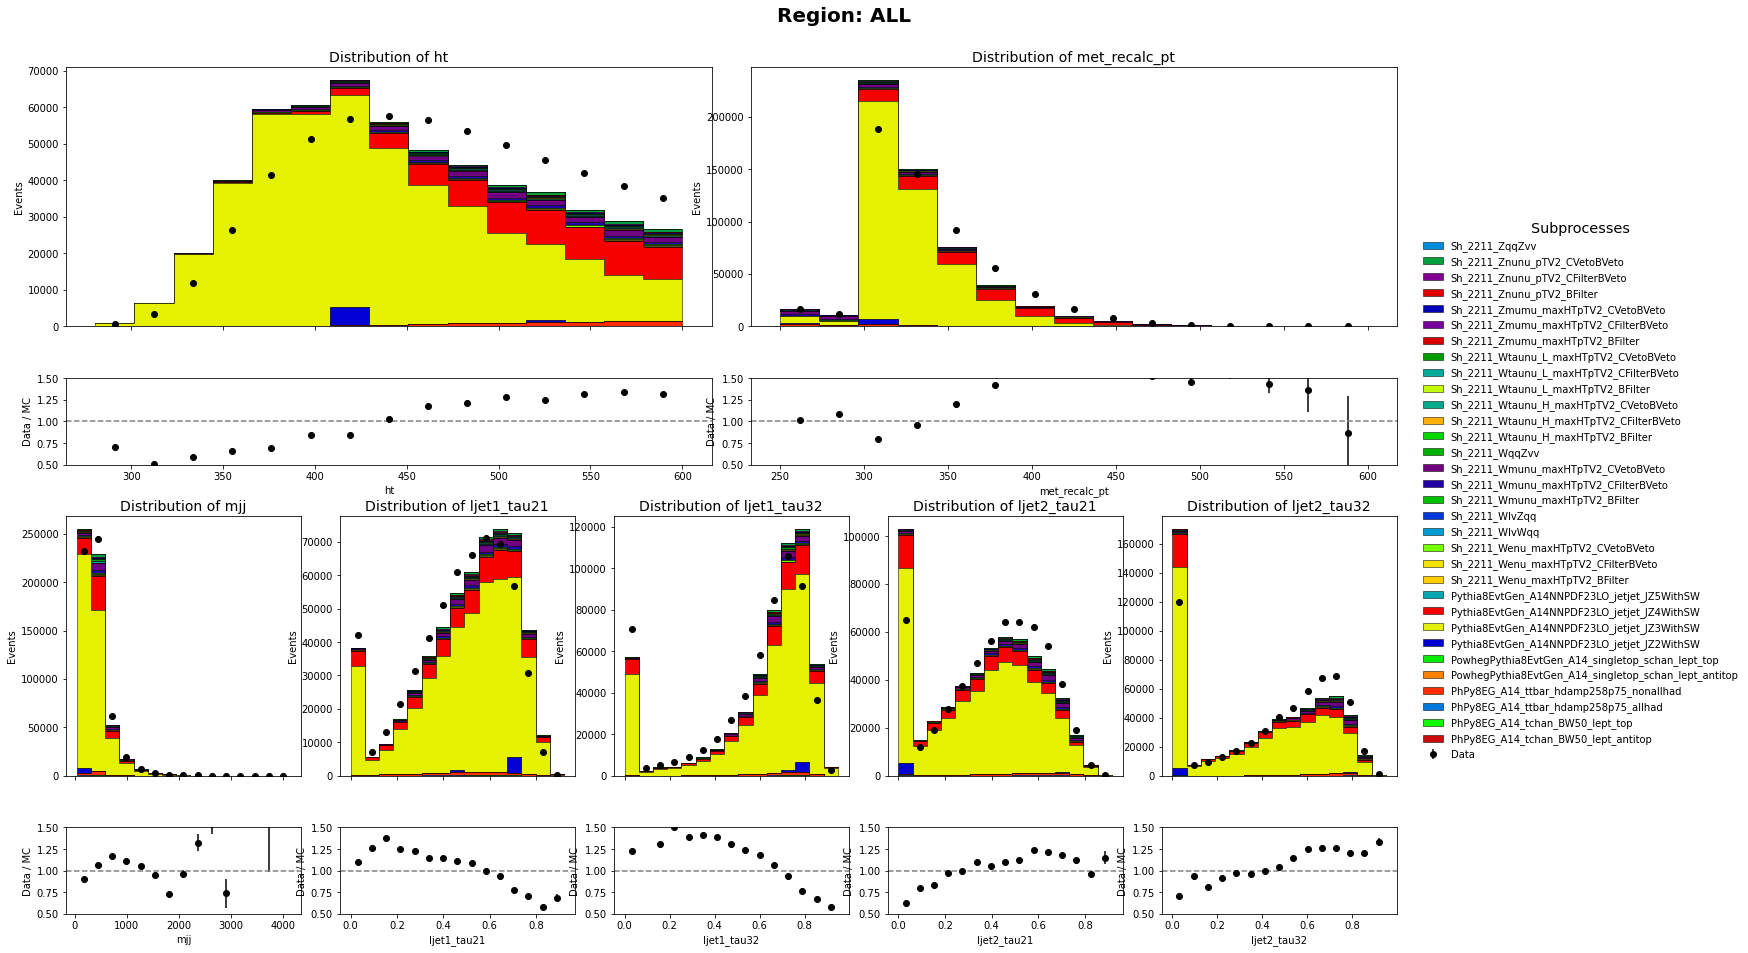

mc_process,subprocess,raw_weights,weight_ngen,weight_sub_weight,weight_tot_weight,met_recalc_pt,met_recalc_phi,ht,mjj,ljet1_tau21,ljet1_tau32,ljet2_tau21,ljet2_tau32,crossSection_pb,genFiltEff,kFactor,sumOfWeights,sum_w_pros,scale_factor_sub_weight,luminosity,official_scale_factor,final_weight
str,str,f32,f64,f32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ttbar""","""PhPy8EG_A14_ttbar_hdamp258p75_…",736.378784,0.926464,0.001269,0.076849,476.104858,-0.711279,574.401062,576.679138,0.465204,0.758297,0.521001,0.341235,729.77,0.5437965,1.139756,2.4015e10,1.4545e10,0.000786,25.289005,0.000786,0.984465
"""ttbar""","""PhPy8EG_A14_ttbar_hdamp258p75_…",736.378784,0.926464,0.001269,0.076849,297.739014,2.405912,456.841675,295.770935,0.580662,0.608273,0.0,0.0,729.77,0.5437965,1.139756,2.4015e10,1.4545e10,0.000786,25.289005,0.000786,0.984465
"""ttbar""","""PhPy8EG_A14_ttbar_hdamp258p75_…",735.81134,0.926464,0.001269,0.076849,341.876404,2.730072,489.017151,475.931152,0.563068,0.200206,0.708507,0.669335,729.77,0.5437965,1.139756,2.4015e10,1.4545e10,0.000786,25.289005,0.000786,0.983706
"""ttbar""","""PhPy8EG_A14_ttbar_hdamp258p75_…",735.651062,0.926464,0.001269,0.076849,278.82074,-0.010655,388.424591,291.516724,0.746014,0.666681,0.512413,0.723921,729.77,0.5437965,1.139756,2.4015e10,1.4545e10,0.000786,25.289005,0.000786,0.983492
"""ttbar""","""PhPy8EG_A14_ttbar_hdamp258p75_…",735.903809,0.926464,0.001269,0.076849,337.199707,2.998439,414.683167,257.069672,0.690459,0.630164,0.406315,0.582162,729.77,0.5437965,1.139756,2.4015e10,1.4545e10,0.000786,25.289005,0.000786,0.98383
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Diboson""","""Sh_2211_WlvZqq""",7915.406738,0.516739,0.000019,0.001187,424.753662,-0.595502,586.676575,129.017212,0.419772,0.498201,0.359574,0.783146,8.5822,1.0,1.0,1.8287e10,1.1533e10,0.000019,25.289005,0.000019,0.148955
"""Diboson""","""Sh_2211_WlvZqq""",6454.037598,0.516739,0.000019,0.001187,314.219482,-2.312726,539.76532,103.78215,0.108797,0.74284,0.570198,0.479036,8.5822,1.0,1.0,1.8287e10,1.1533e10,0.000019,25.289005,0.000019,0.121454
"""Diboson""","""Sh_2211_WlvZqq""",5955.148438,0.516739,0.000019,0.001187,407.372925,2.436208,584.356262,187.893173,0.617745,0.746029,0.219728,0.823659,8.5822,1.0,1.0,1.8287e10,1.1533e10,0.000019,25.289005,0.000019,0.112066


In [12]:
plot_subprocess_data_comparison(mc_total_df, data_total_df, "ALL")

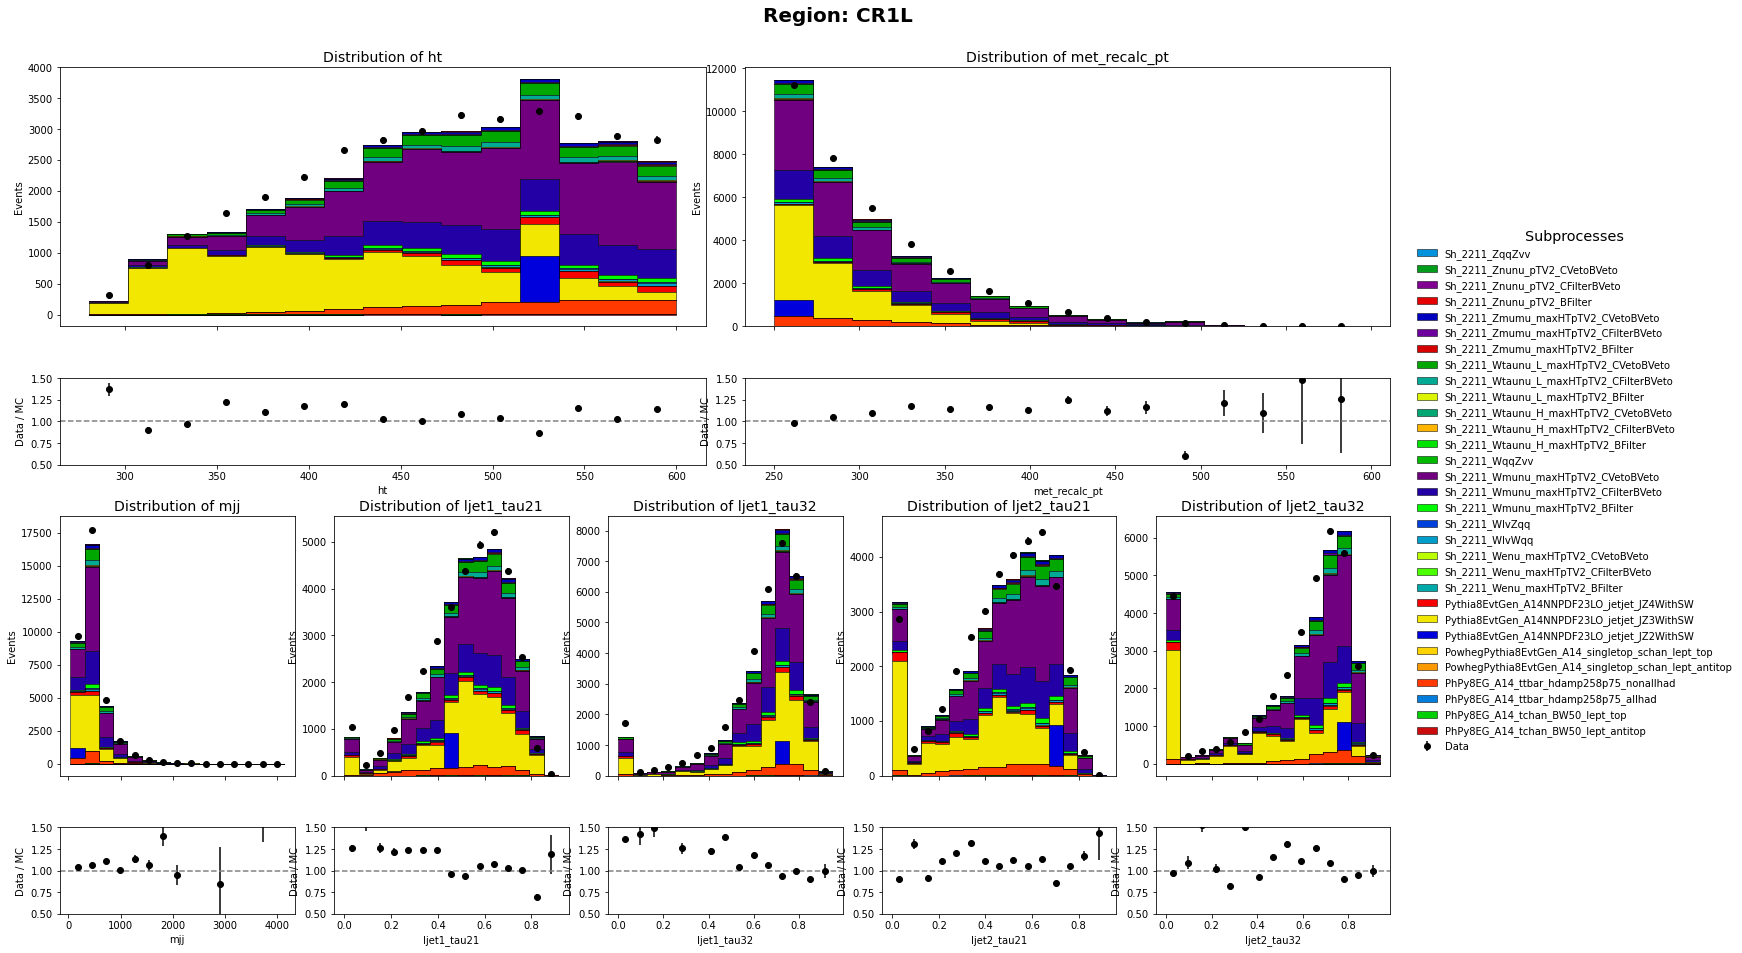

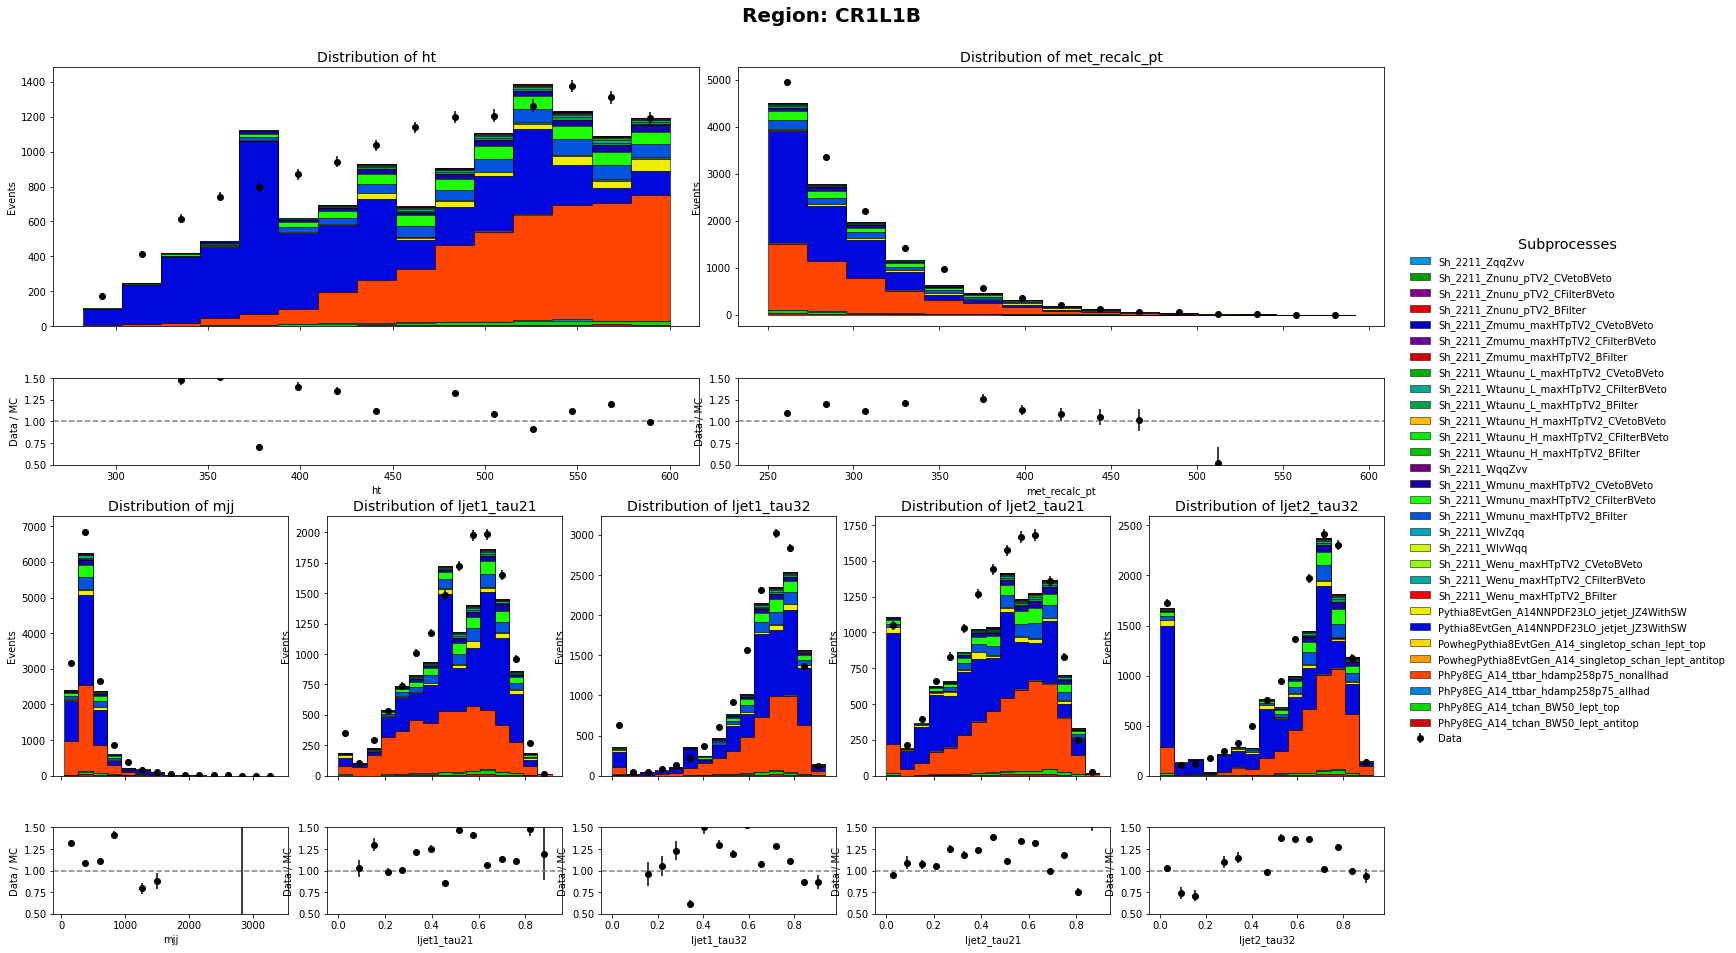

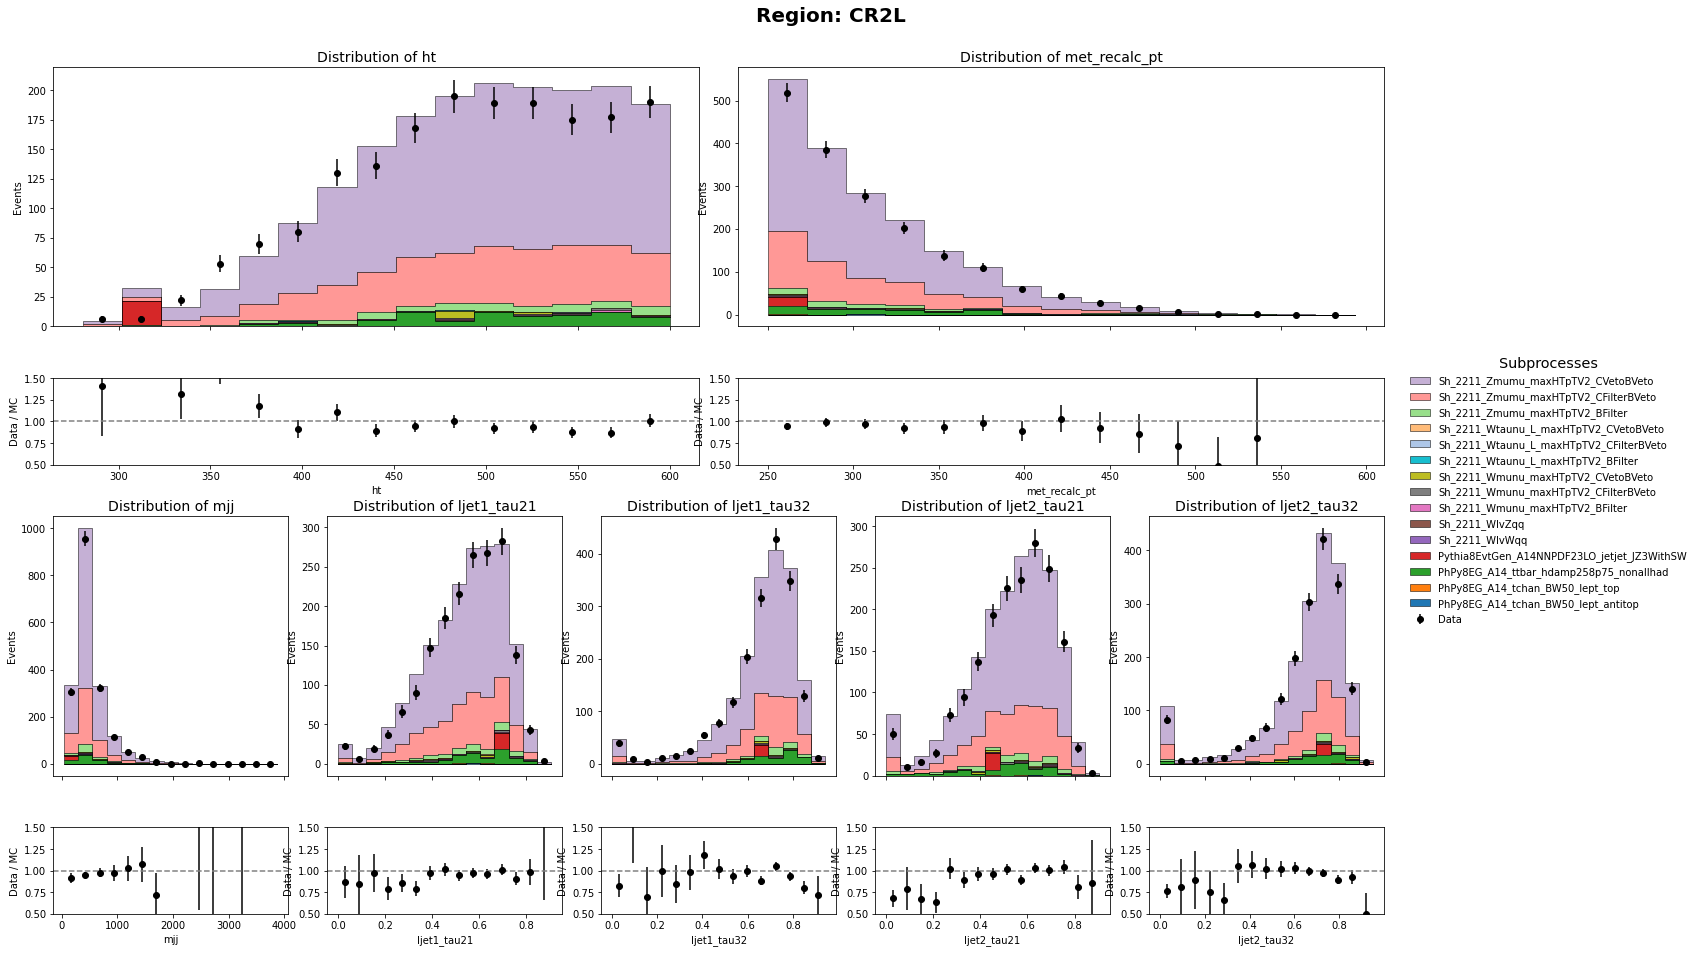

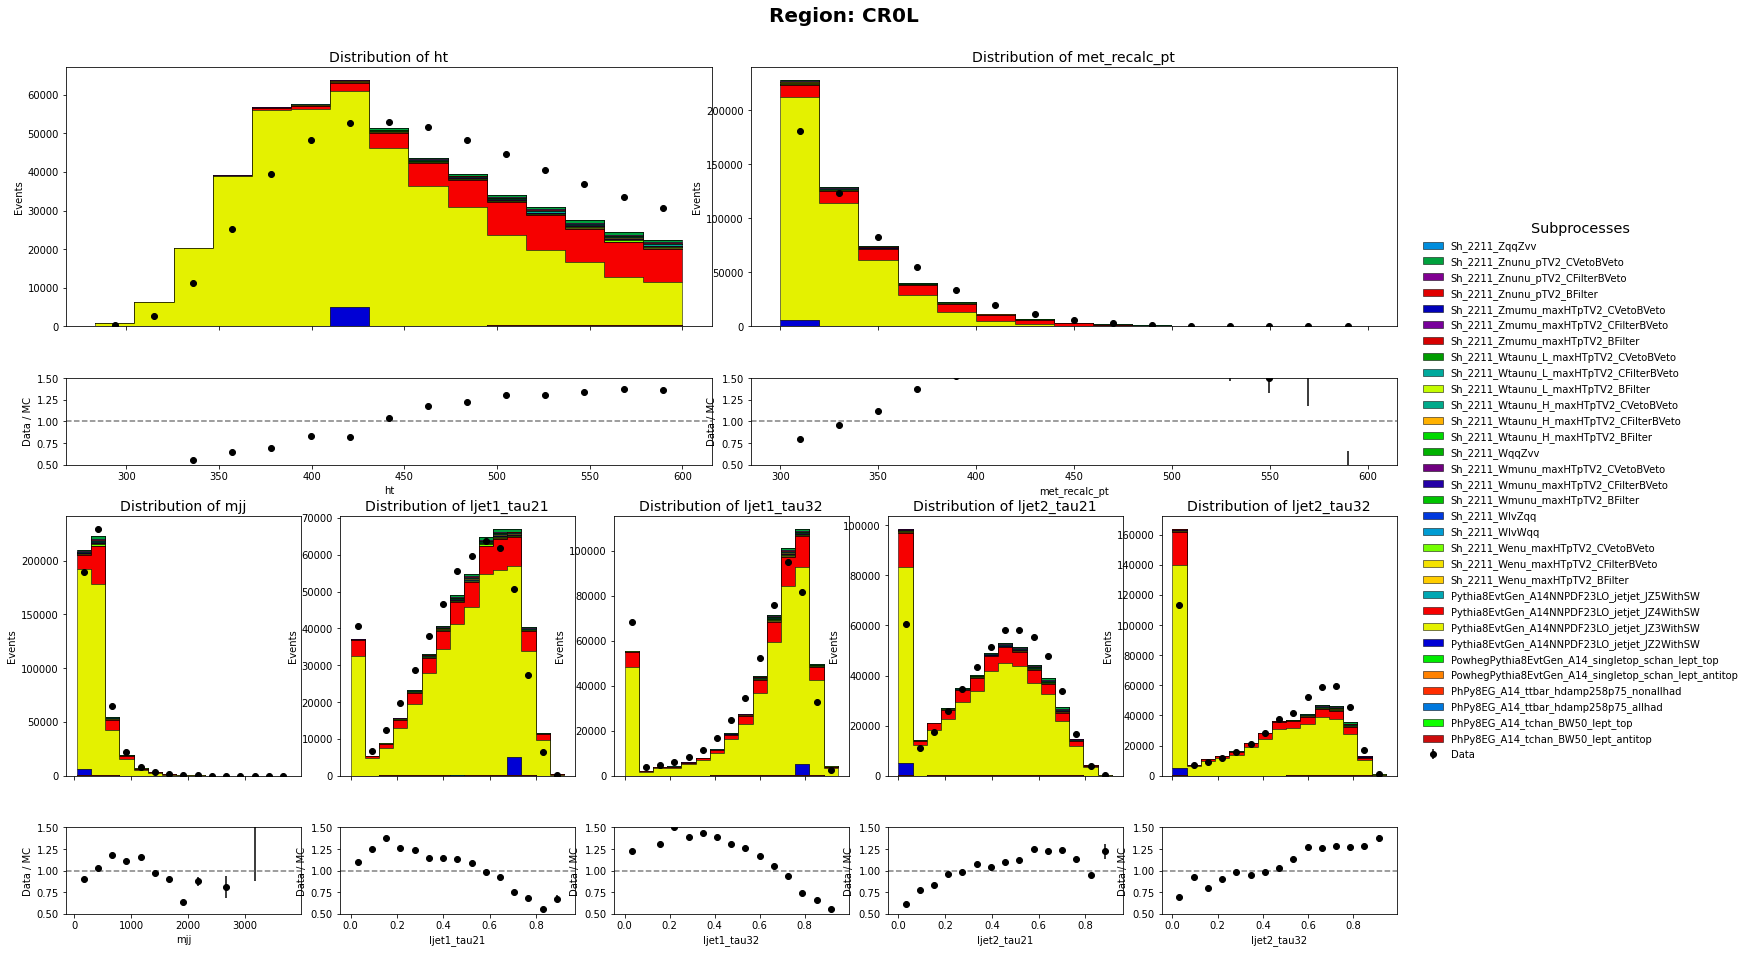

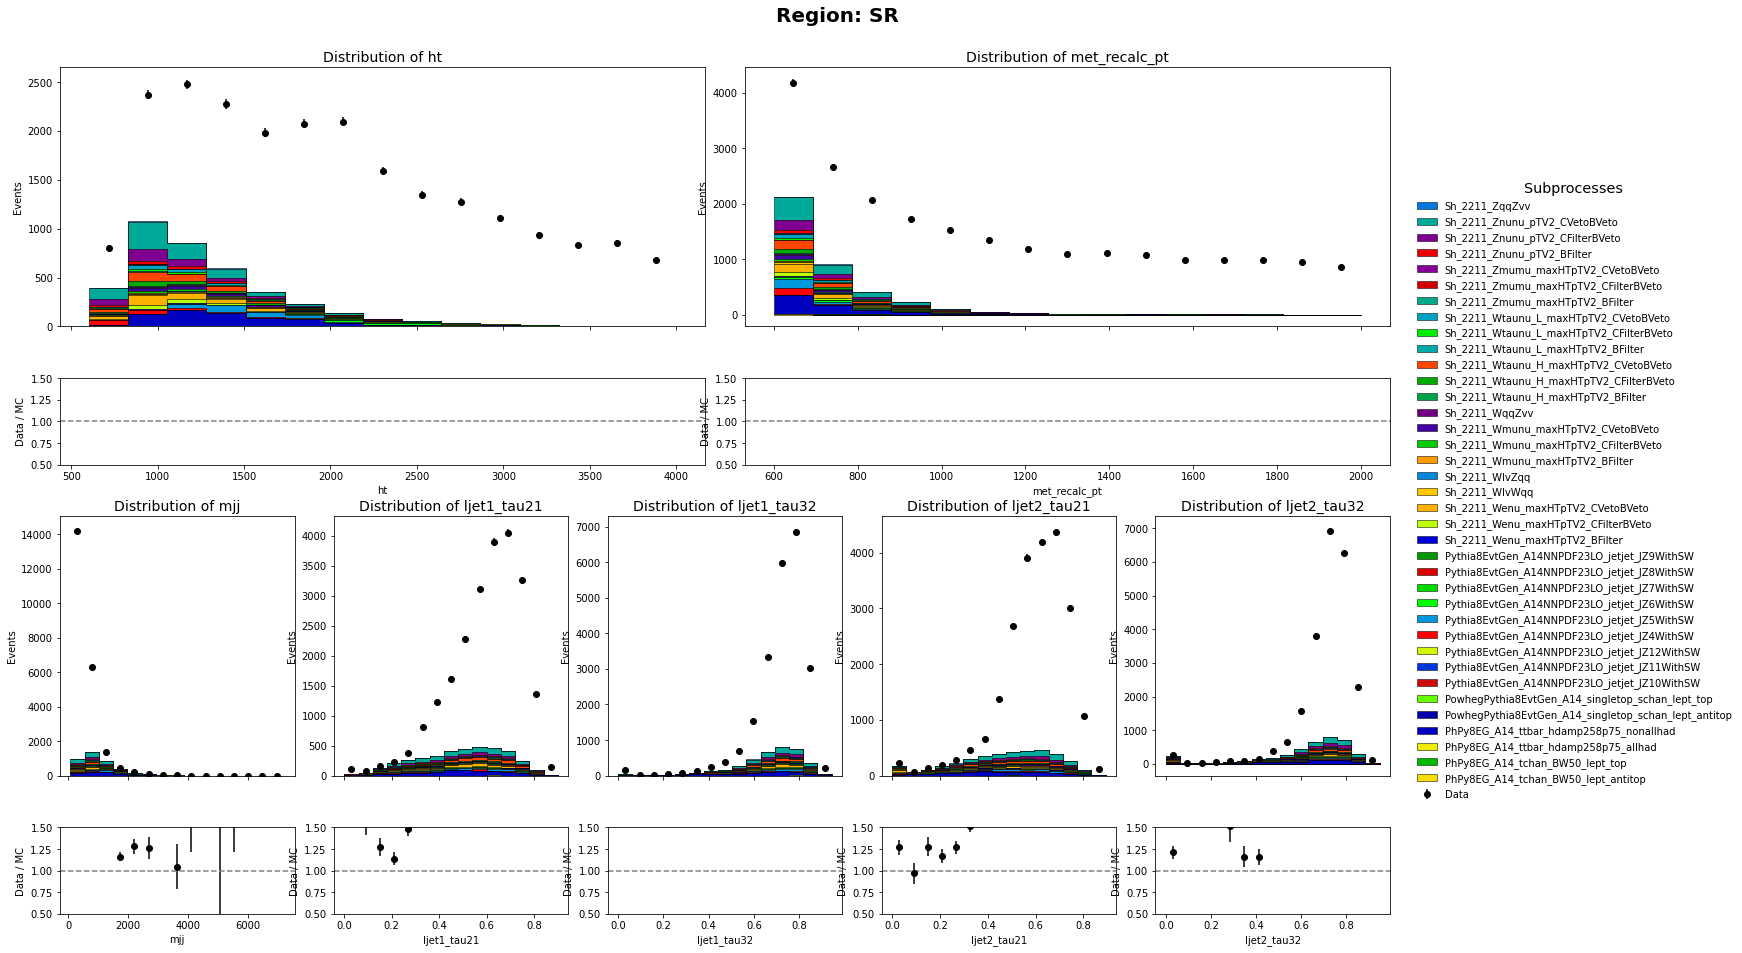

In [13]:
# procs_to_remove = ["Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ1WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW"]
# df_mc = MC_CR1L.filter(~pl.col("subprocess").is_in(procs_to_remove))


for mc_df, data_df, region in zip(
    [MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR0L_test, MC_SR_clean], 
    [DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR0L_test, DATA_SR_clean], 
    ["CR1L", "CR1L1B", "CR2L", "CR0L", "SR"]
):
    plot_subprocess_data_comparison(mc_df, data_df, region_name=region)

Generating plots for: 1-Lepton CR (W+jets dominated)


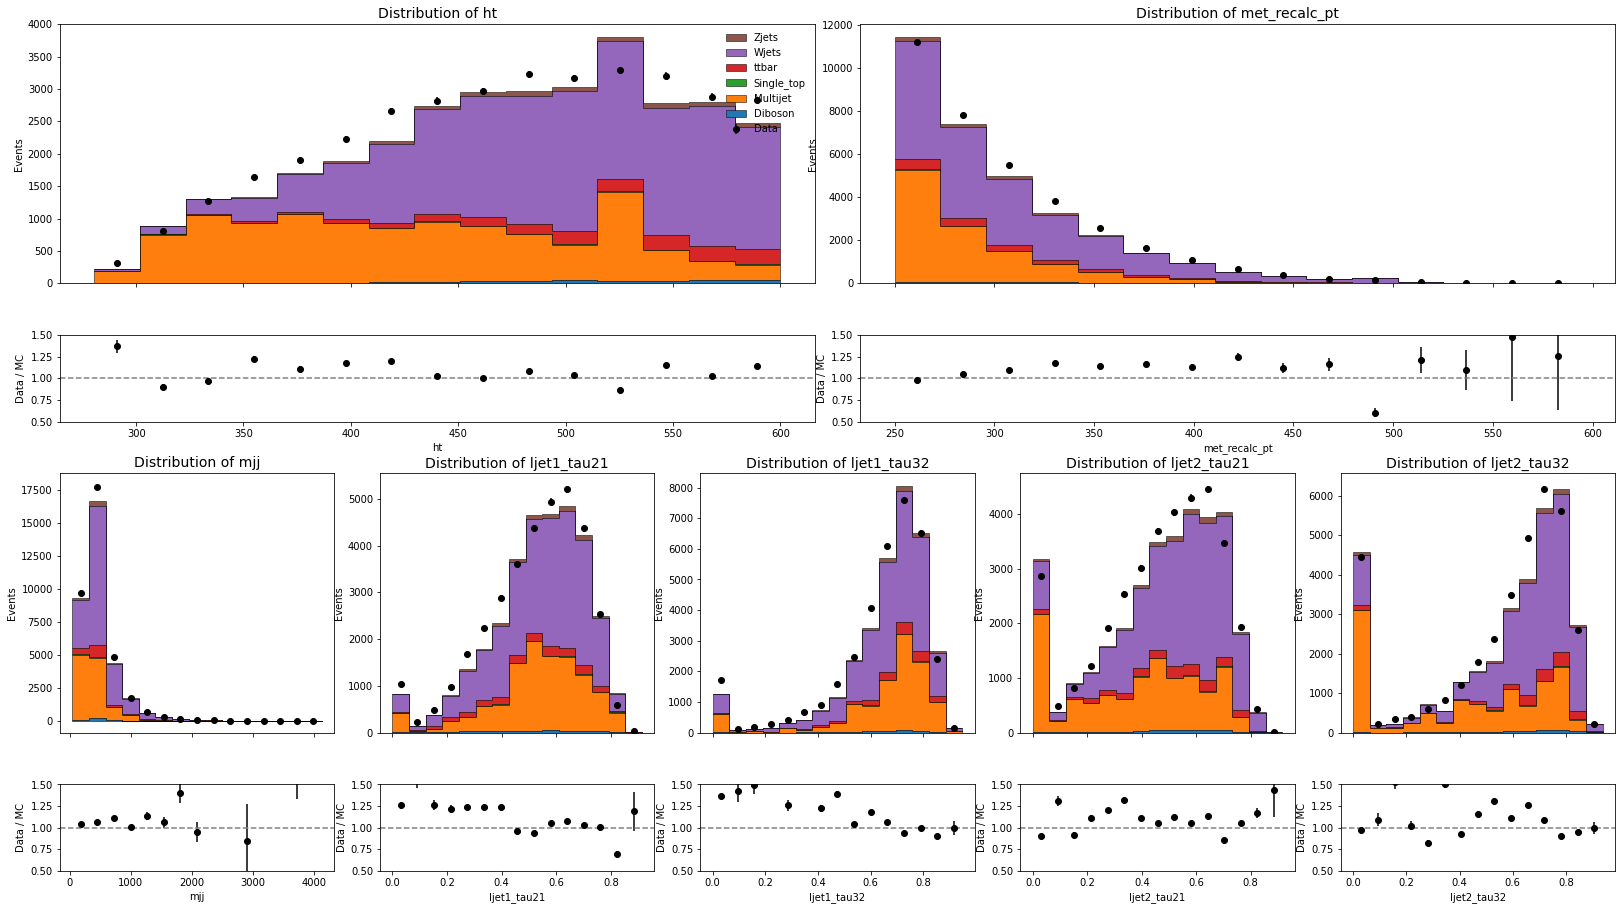

Generating plots for: 1-Lepton 1-Btag CR (Top dominated)


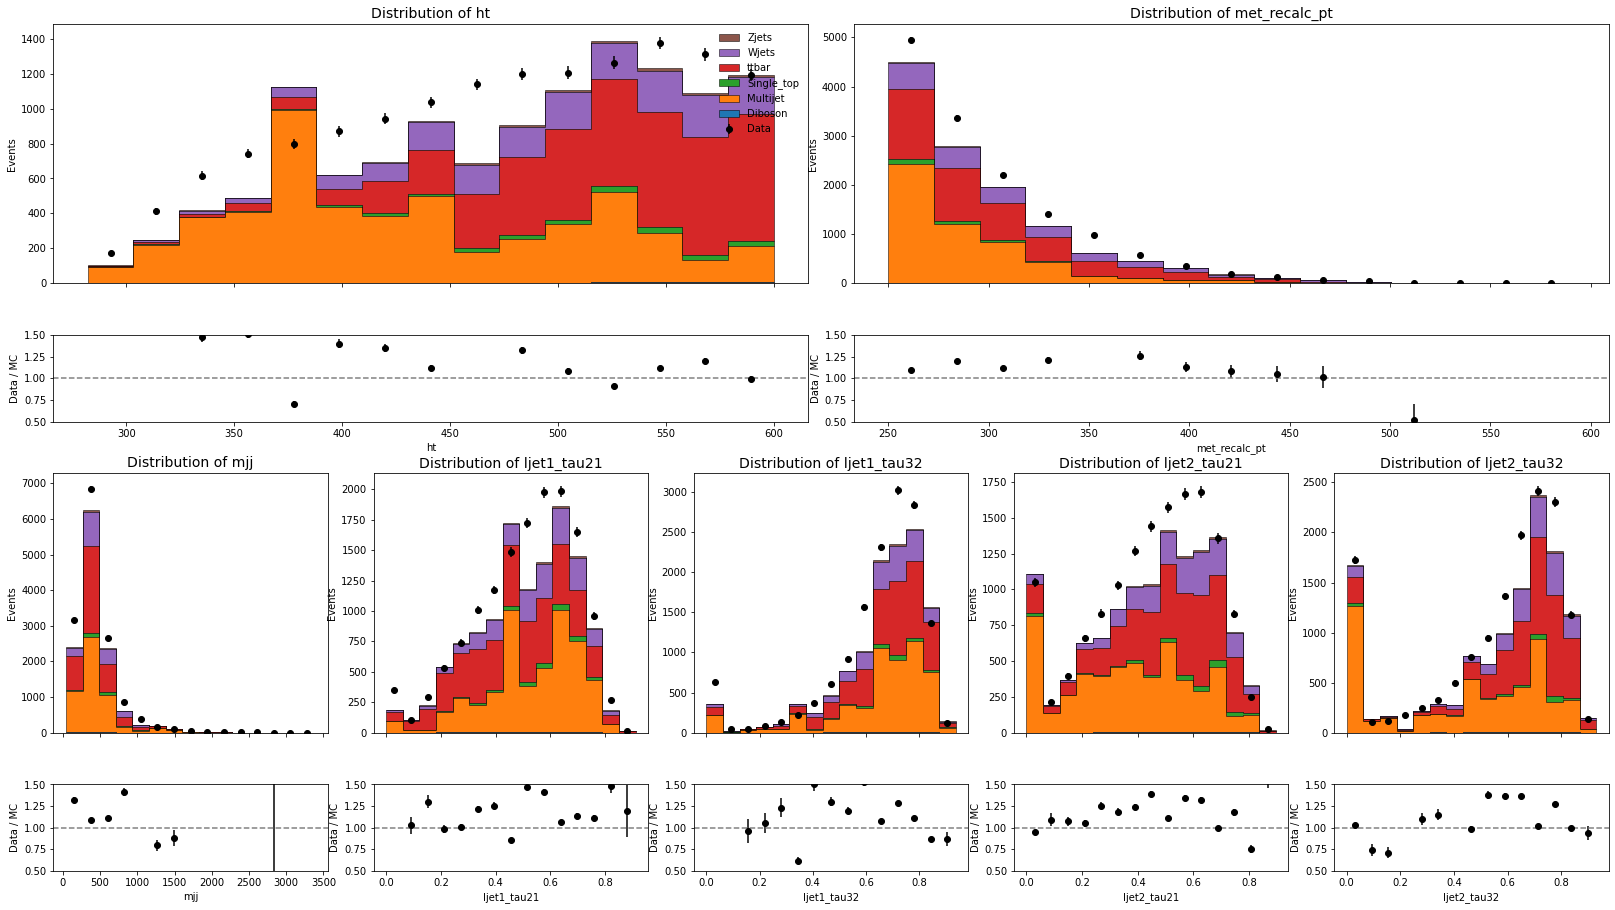

Generating plots for: 2-Lepton CR (Z+jets dominated)


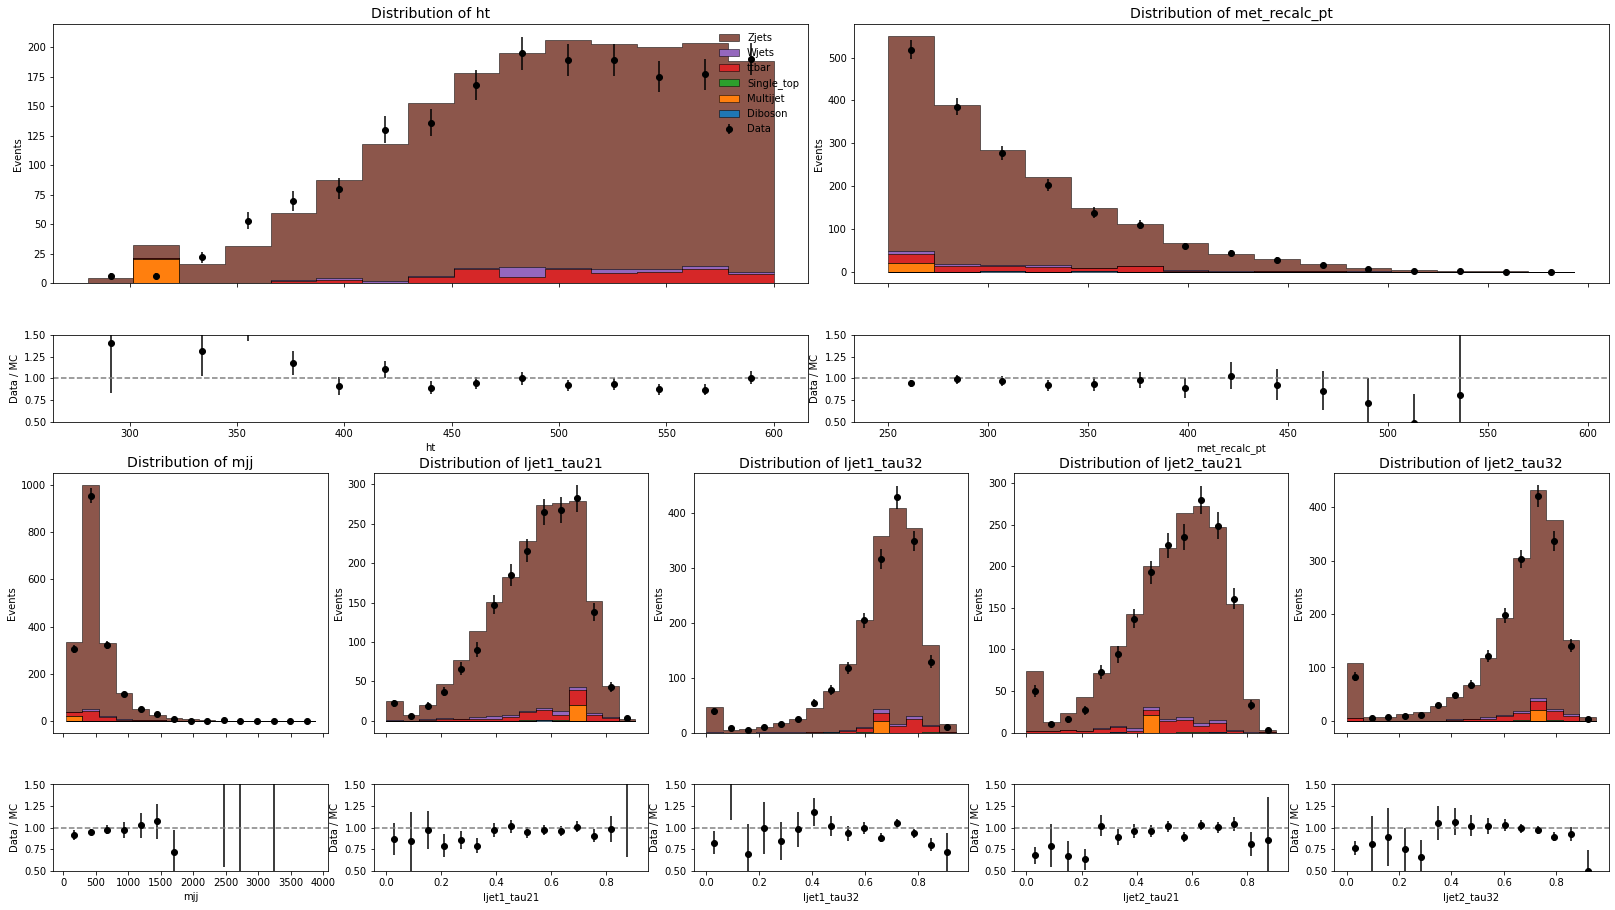

Generating plots for: 0-Lepton CR (Multijet dominated)


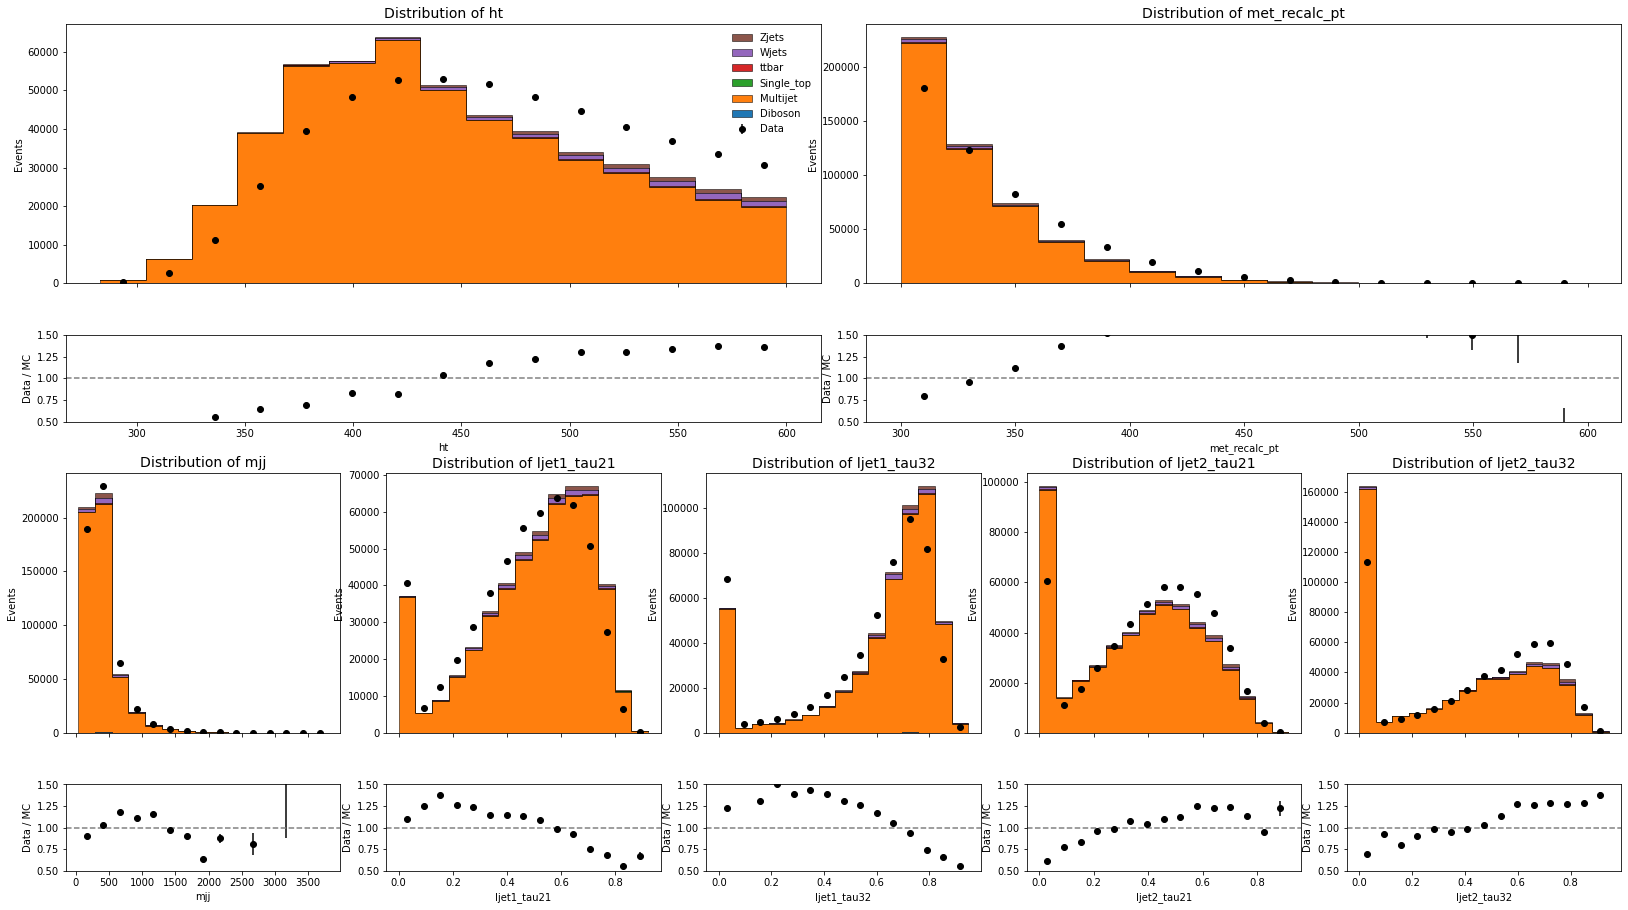

In [14]:
# Group your pre-loaded DataFrames by region
regions = {
    "1-Lepton CR (W+jets dominated)": (MC_CR1L, DATA_CR1L),
    "1-Lepton 1-Btag CR (Top dominated)": (MC_CR1L1B, DATA_CR1L1B),
    "2-Lepton CR (Z+jets dominated)": (MC_CR2L, DATA_CR2L),
    "0-Lepton CR (Multijet dominated)": (MC_CR0L_test, DATA_CR0L_test)
}

# Plot each region independently
for region_name, (mc_df, data_df) in regions.items():
    print(f"Generating plots for: {region_name}")
    
    # Optional: You can pass region_name to plot_mc_data_comparison 
    # to use it in your ax_main.set_title() so you know which plot is which!
    plot_mc_data_comparison(mc_df, data_df)

### Split and Scale Samples

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib  # For saving the scaler

# MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR2L1B, MC_CR0L, MC_SR_clean
# DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR2L1B, DATA_CR0L, DATA_SR_clean

In [17]:
import os
import joblib
import numpy as np
import polars as pl
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# =====================================================================
# 1. SETUP AND FEATURE DEFINITIONS
# =====================================================================

output_dir = Path("Final_Dataset")
output_dir.mkdir(parents=True, exist_ok=True)

# The exact features that the Normalizing Flow and Classifier will see
features_to_scale = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# Group the existing DataFrames into dictionaries
mc_datasets = {
    "MC_CR1L": MC_CR1L,
    "MC_CR1L1B": MC_CR1L1B,
    "MC_CR2L": MC_CR2L,
    "MC_CR0L": MC_CR0L_test,
    "MC_SR_clean": MC_SR_clean
}

data_datasets = {
    "DATA_CR1L": DATA_CR1L,
    "DATA_CR1L1B": DATA_CR1L1B,
    "DATA_CR2L": DATA_CR2L,
    "DATA_CR0L": DATA_CR0L_test,
    "DATA_SR_clean": DATA_SR_clean
}

# =====================================================================
# 2. CALCULATE AND PRINT GRANULAR TRAINING STATISTICS
# =====================================================================
print("="*85)
print(" 📊 DATASET STATISTICS (BEFORE SCALING)")
print("="*85)

all_mc_features = []

for name in mc_datasets.keys():
    region = name.replace("MC_", "")
    df_mc = mc_datasets[name]
    df_data = data_datasets.get(f"DATA_{region}")
    
    # 1. Data Count
    n_data = df_data.height if df_data is not None else 0
    
    print(f"\nREGION: {region}")
    print(f"Total Data Events: {n_data}")
    print("-" * 85)
    print(f"{'Process':<15} | {'Subprocess':<35} | {'MC Events':<10} | {'MC Yield (SumW)':<15}")
    print("-" * 85)
    
    # 2. MC Granular Breakdown
    if df_mc is not None and df_mc.height > 0:
        # Determine which weight column to sum
        weight_col = "final_weight"
        
        # Use Polars group_by for blazing fast aggregations
        mc_stats = (
            df_mc.group_by(["mc_process", "subprocess"])
            .agg([
                pl.len().alias("count"),
                pl.col(weight_col).sum().alias("yield")
            ])
            .sort(["mc_process", "subprocess"])
        )
        
        # Print the breakdown
        for row in mc_stats.iter_rows(named=True):
            print(f"{row['mc_process']:<15} | {row['subprocess']:<35} | {row['count']:<10} | {row['yield']:<15.2f}")
            
        # Add to our global boundaries collection
        all_mc_features.append(df_mc.select(features_to_scale))
    else:
        print("No MC data found for this region.")

print("\n--- Global MC Boundaries (Across All Regions) ---")
# Concatenate all MC to calculate raw boundaries and fit the scaler
df_all_mc = pl.concat(all_mc_features)
X_all_mc = df_all_mc.to_numpy()

print(f"{'Feature':<15} | {'Global Min':<12} | {'Global Max':<12}")
print("-" * 45)
for i, f in enumerate(features_to_scale):
    f_min = X_all_mc[:, i].min()
    f_max = X_all_mc[:, i].max()
    print(f"{f:<15} | {f_min:<12.2f} | {f_max:<12.2f}")
print("="*85 + "\n")

# =====================================================================
# 3. FIT SCALER ON MC ONLY AND SAVE IT
# =====================================================================
print("Fitting MinMaxScaler on combined MC...")

# Initialize the scikit-learn scaler to the (-2.5, 2.5) range
scaler = MinMaxScaler(feature_range=(-2.5, 2.5))
scaler.fit(X_all_mc)

# Save the fitted scaler to the Final_Dataset folder
scaler_path = output_dir / "minmax_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"Scaler successfully saved to {scaler_path}\n")

# =====================================================================
# 4. TRANSFORMATION FUNCTION (NUMPY <-> POLARS BRIDGE)
# =====================================================================
def scale_dataframe(df: pl.DataFrame, fitted_scaler: MinMaxScaler, features: list) -> pl.DataFrame:
    """
    Extracts features, scales them using the fitted sklearn scaler, clips outliers,
    and safely overwrites the columns in the Polars DataFrame.
    """
    X_raw = df.select(features).to_numpy()
    
    # Transform using the pre-fitted scaler
    X_scaled = fitted_scaler.transform(X_raw)
    
    # STRICT CLIPPING: Enforce the (-2.5, 2.5) bounds
    X_scaled = np.clip(X_scaled, -2.5, 2.5)
    
    # Create a list of Polars Series to overwrite the old unscaled columns
    scaled_series = [pl.Series(name=f, values=X_scaled[:, i]) for i, f in enumerate(features)]
    
    return df.with_columns(scaled_series)

# =====================================================================
# 5. APPLY TRANSFORMATION AND EXPORT TO PARQUET
# =====================================================================
print("Applying scaler to all MC and Data regions and saving to Parquet...")

all_datasets = {**mc_datasets, **data_datasets}

for name, df in all_datasets.items():
    if df is None or df.height == 0:
        print(f"Skipping {name}: DataFrame is empty or missing.")
        continue
        
    # Scale the DataFrame using our bridge function
    scaled_df = scale_dataframe(df, scaler, features_to_scale)
    
    # Save to Parquet
    file_path = output_dir / f"{name}.parquet"
    scaled_df.write_parquet(file_path)
    
    print(f"Saved: {file_path} (Shape: {scaled_df.shape})")

print("\nPipeline complete! All data scaled and ready for PyTorch.")

 📊 DATASET STATISTICS (BEFORE SCALING)

REGION: CR1L
Total Data Events: 35189
-------------------------------------------------------------------------------------
Process         | Subprocess                          | MC Events  | MC Yield (SumW)
-------------------------------------------------------------------------------------
Diboson         | Sh_2211_WlvWqq                      | 1943       | 266.68         
Diboson         | Sh_2211_WlvZqq                      | 583        | 88.32          
Diboson         | Sh_2211_WqqZvv                      | 8          | 1.37           
Diboson         | Sh_2211_ZqqZvv                      | 3          | 0.36           
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ2WithSW | 1          | 743.57         
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW | 415        | 9774.32        
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW | 329        | 649.63         
Single_top      | PhPy8EG_A14_tchan_BW50_lept_